# Exercise 1: Linear and Logistic Regression with Error Estimation


## Instructions






### Setup check

Run the cell below before you begin. Every entry should report `found`.

In [283]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join("datasets", filename)
    status = "found" if os.path.isfile(path) else "MISSING" 
    print(f"{filename:<16} {status}")

Python 3.12.4
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


---
# Part A. Linear regression

## Program 1. Ordinary least squares regression, from first principles and with `scikit-learn`

### Aim

To implement simple linear regression in Python without a machine learning library, to reproduce
the same fit using `scikit-learn`, and to attach an uncertainty estimate to the fitted
coefficients.

### Theory

The regression line is written as $y = b_0 + b_1 x$. The least squares estimates of the two
coefficients are

$$
\newcommand{\vect}{\mathbf}
\begin{align}
b_1 &= \frac{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})^2}
= \frac{(\vect{x}-\bar{x})^T(\vect{y}-\bar{y})}{(\vect{x}-\bar{x})^T(\vect{x}-\bar{x})}
\\
b_0 &= \bar{y}-b_1\bar{x}
\end{align}
$$

The quality of the fit is summarised by

$$
\begin{align}
\text{RMSE} &= \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y_i})^2}
= \sqrt{\frac{(\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})}{m}}
\\
\text{SS}_{\text{tot}} &= \sum_{i=1}^{m}(y_i - \bar{y})^2 = (\vect{y}-\bar{y})^T(\vect{y}-\bar{y})
\\
\text{SS}_{\text{res}} &= \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = (\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})
\\
R^{2} &= 1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\end{align}
$$

where $\vect{x} = (x_1,x_2,\dots,x_m)$ is the input vector, $\vect{y} = (y_1,y_2,\dots,y_m)$ is the
output vector, $\bar{x}$ and $\bar{y}$ are the corresponding means, and
$\hat{\vect{y}} = (\hat{y}_1,\hat{y}_2,\dots,\hat{y}_m)$ is the vector of predicted values.

Under the usual assumption of independent errors of constant variance, the standard errors of the
two coefficients follow from the residual variance
$s^2 = \text{SS}_{\text{res}}/(m-2)$:

$$
\begin{align}
\text{SE}(b_1) &= \sqrt{\frac{s^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}}
\\
\text{SE}(b_0) &= \sqrt{s^2\left[\frac{1}{m} + \frac{\bar{x}^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}\right]}
\end{align}
$$

The divisor $m-2$ appears because two parameters have already been estimated from the same data.

### TASK A1. Implementing the regression class 

Complete the three methods of the class below. Use vectorised NumPy operations only, without an
explicit Python loop over the samples, and without importing `scikit-learn`.

In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [290]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        """Estimate b0 and b1 from one-dimensional arrays X and y.

        Stores the results as self.b0 and self.b1 and returns self.
        """
        m = X.shape[0]

        # TODO 
        # 1. compute the means of X and y
        xmean = np.mean(X)
        ymean = np.mean(y)
        # 2. compute the mean-centred vectors
        xc = X-xmean
        yc = y-ymean
        # 3. obtain b1 from the ratio of the two inner products given in the theory section
        b1 = np.sum(xc*yc)/np.sum(xc**2)
        # 4. obtain b0 from b1 and the two means
        b0 =  ymean- b1*xmean
        # 5. store them as self.b0 and self.b1
        self.b1 = b1
        self.b0 = b0
        # 6. print the pair in the format
        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self

        ##raise NotImplementedError("Task A1: complete fit(), then delete this line")

    def predict(self, X):
        """Return the predicted response for the array X."""

        # TODO (1 mark)
        y_pred = self.b0 + self.b1*X
        return y_pred
       ## raise NotImplementedError("Task A1: complete predict(), then delete this line")

    def evaluate(self, X, y):
        """Print and return the RMSE and the R^2 score as a tuple."""

        y_pred = self.predict(X)
        rmse = np.sqrt(np.mean((y-y_pred)**2))
        ss_tot = np.sum((y-np.mean(y))**2)
        ss_res = np.sum((y-y_pred)**2)
        r2 = 1 - (ss_res/ss_tot)

        # TODO 
        # compute rmse, ss_tot, ss_res and r2 using the formulae above

        # then print them as
        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(r2, 3))
        return (rmse, r2)

        ##raise NotImplementedError("Task A1: complete evaluate(), then delete this line")

### TASK A2. Plotting the fit

Complete the plotting helper. The scatter of the observed data and the fitted straight line must
appear on the same axes.

def regression_plot(X, y, model, title=""):
    """Scatter plot of the data with the fitted regression line drawn over it."""
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # TODO
    # 1. label the x axis as "Head size (cm^3)" and the y axis as "Brain weight (grams)"
    # 2. build a two-element array x_line spanning slightly beyond the data range,
    #    shaped as a column so that both implementations of predict() accept it
    # 3. evaluate the model on x_line to obtain y_line
    # 4. draw the observed points with plt.scatter and the fitted line with plt.plot
    # 5. add a legend and show the figure

    raise NotImplementedError("Task A2: complete regression_plot(), then delete this line")

In [294]:
def regression_plot(X, y, model, title=""):
    plt.figure(figsize=(10, 6)) 
    plt.title(title)
    x = X
    #1 
    plt.xlabel("Head size (cm^3)")
    plt.ylabel("Brain weight (grams)")
    #2
    xl=np.array([x.min()-10,x.max()+10]).reshape(-1, 1)
    #3
    yl = model.predict(xl)
    #3]4
    plt.scatter(x,y,color = 'g',label = 'observed data')
    plt.plot(xl,yl,color = 'r' ,label = 'fitted line')
    #5
    plt.legend()
    plt.show()

### TASK A3. Fitting the head and brain dataset 

The dataset relates the head size of an adult to the mass of the brain. Load it, extract the two
columns of interest, fit the model, plot the result, and evaluate the fit.

In [297]:
# TODO : read datasets/headbrain.csv into a DataFrame named data,
# then print its shape and display the first five rows
data = pd.read_csv("datasets/headbrain.csv")
print(data.shape)
data.head()


(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [299]:
# TODO : extract the predictor and the response as one-dimensional NumPy arrays
X = data["Head Size(cm^3)"].to_numpy()  # column "Head Size(cm^3)"
y = data["Brain Weight(grams)"].to_numpy() # column "Brain Weight(grams)"
print(X.shape)
print(y.shape)


(237,)
(237,)


(b0, b1) = (325.573, 0.263)


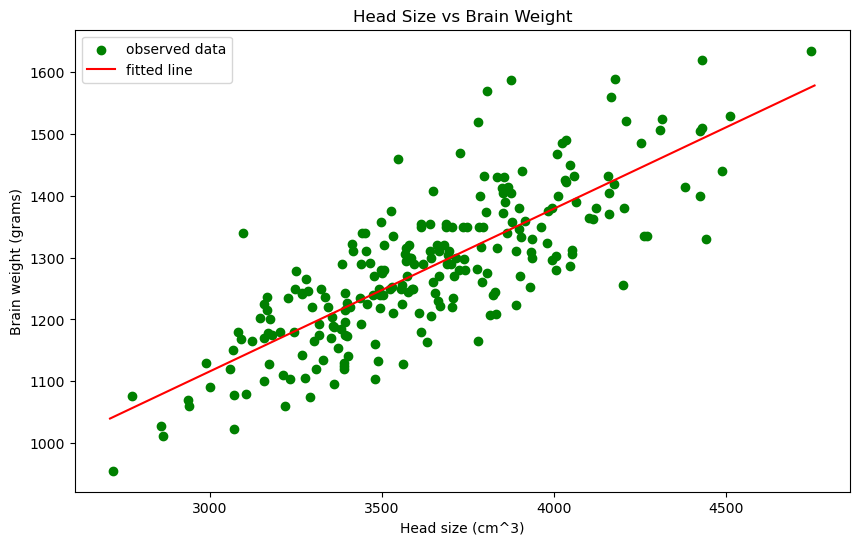

Root mean squared error: 72.121
R^2 value: 0.639


(72.1206213783709, 0.639311719957)

In [301]:
# TODO : create the model, fit it, plot the fit, and evaluate it
model = LinearRegression()
model.fit(X,y)
regression_plot(X,y,model, title="Head Size vs Brain Weight")
model.evaluate(X,y)

### TASK A4. Comparison with `scikit-learn` 

Repeat the fit with the library estimator and confirm that the two implementations agree.

Note that `scikit-learn` expects a two-dimensional array of predictors, so the input has to be
reshaped from `(m,)` to `(m, 1)`.

In [304]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

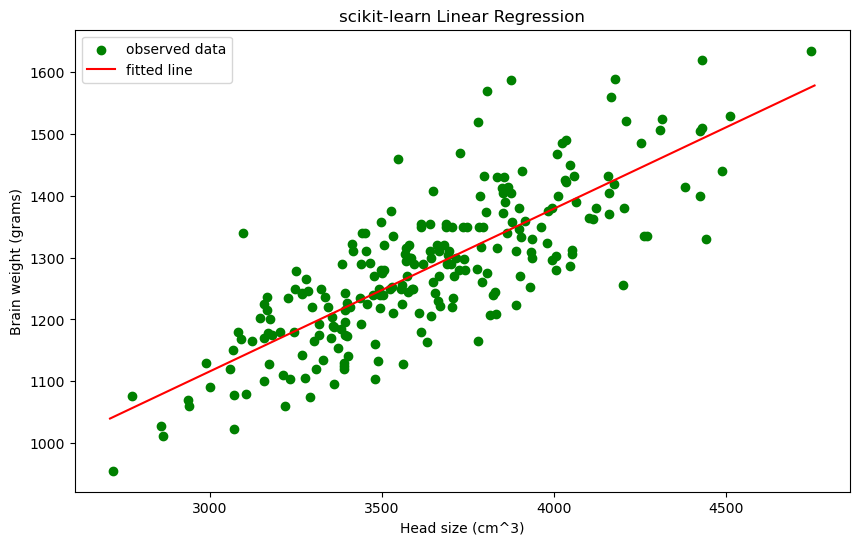

Intercept (b0): 325.5734210494428
Coefficient (b1): 0.2634293394893993
Root mean squared error: 72.121
R^2 value: 0.639
Difference in b0: 0.0
Difference in b1: 0.0


In [306]:
# TODO 
# 1. fit SkLinearRegression on X1 and y
# 2. reuse regression_plot to display the fit
# 3. print the intercept and the coefficient, the RMSE, and the R^2 score
# 4. print the absolute difference between your own b0, b1 and the library values
#1
sk_model =SkLinearRegression()
sk_model.fit(X1,y)
#2
regression_plot(X,y,sk_model,title = "scikit-learn Linear Regression")
#3
y_pred = sk_model.predict(X1)
rmse = np.sqrt(mean_squared_error(y,y_pred))
r2 = sk_model.score(X1,y)
print("Intercept (b0):", sk_model.intercept_)
print("Coefficient (b1):", sk_model.coef_[0])
print("Root mean squared error:", round(rmse, 3))
print("R^2 value:", round(r2, 3))

#4
print("Difference in b0:" , abs(model.b0-sk_model.intercept_))
print("Difference in b1:" , abs(model.b1-sk_model.coef_[0]))


### TASK A5. Error estimation 

A coefficient reported without an uncertainty is of limited scientific value. In this task the
uncertainty is estimated in two independent ways, first from the analytical expressions given in
the theory section and then by resampling.

The 95 per cent confidence interval of a coefficient is approximated as
$b \pm t_{0.975,\,m-2}\,\text{SE}(b)$, where the critical value is close to 1.96 for a sample of
this size.

In [309]:
def coefficient_standard_errors(X, y, model):
    # Return (se_b0, se_b1) for a fitted simple linear regression model.

    # TODO 
    # 1. obtain the residuals y - model.predict(X)
    # 2. compute the residual variance s^2 with the correct number of degrees of freedom
    # 3. compute the two standard errors from the expressions in the theory section
    
    #1
    residuals  = y - model.predict(X)
    #2
    m = len(X)
    s2 = np.sum(residuals**2)/(m-2)
    #3
    xmean = np.mean(X)
    sxx = np.sum((X-xmean)**2)
    sb1 = np.sqrt(s2/sxx)
    sb0 = np.sqrt(s2*(1/m+(xmean**2)/sxx))
    return(sb0,sb1)


    raise NotImplementedError("Task A5: complete coefficient_standard_errors(), then delete this line")


# TODO: report b0 and b1 together with their standard errors and their 95 per cent
# confidence intervals, in the form  b1 = 0.263 +/- 0.010

sb0,sb1 = coefficient_standard_errors(X, y, model)
t = 1.96
print(f"b0 = {model.b0:.3f} +/- {sb0:.3f}")
print(f"95% CI: ({model.b0 - t *sb0:.3f},{model.b0+t*sb0:.3f})")
print(f"b1 = {model.b1:.3f} +/- {sb1:.3f}")
print(f"95% CI: ({model.b1 - t * sb1:.3f},{model.b1+t*sb1:.3f})")

b0 = 325.573 +/- 47.141
95% CI: (233.177,417.969)
b1 = 0.263 +/- 0.013
95% CI: (0.238,0.289)


(b0, b1) = (378.726, 0.248)
(b0, b1) = (331.318, 0.263)
(b0, b1) = (280.077, 0.276)
(b0, b1) = (271.900, 0.277)
(b0, b1) = (337.163, 0.260)
(b0, b1) = (302.642, 0.270)
(b0, b1) = (279.532, 0.275)
(b0, b1) = (292.682, 0.273)
(b0, b1) = (379.985, 0.250)
(b0, b1) = (279.597, 0.277)
(b0, b1) = (397.224, 0.242)
(b0, b1) = (366.474, 0.251)
(b0, b1) = (295.008, 0.273)
(b0, b1) = (380.039, 0.248)
(b0, b1) = (341.499, 0.258)
(b0, b1) = (415.911, 0.242)
(b0, b1) = (341.483, 0.259)
(b0, b1) = (340.068, 0.261)
(b0, b1) = (315.099, 0.267)
(b0, b1) = (368.813, 0.251)
(b0, b1) = (342.090, 0.259)
(b0, b1) = (259.536, 0.280)
(b0, b1) = (355.545, 0.257)
(b0, b1) = (324.950, 0.263)
(b0, b1) = (315.215, 0.267)
(b0, b1) = (246.109, 0.284)
(b0, b1) = (285.787, 0.276)
(b0, b1) = (361.210, 0.254)
(b0, b1) = (357.297, 0.254)
(b0, b1) = (370.527, 0.251)
(b0, b1) = (291.618, 0.273)
(b0, b1) = (318.630, 0.264)
(b0, b1) = (336.631, 0.261)
(b0, b1) = (399.243, 0.242)
(b0, b1) = (394.947, 0.245)
(b0, b1) = (325.733,

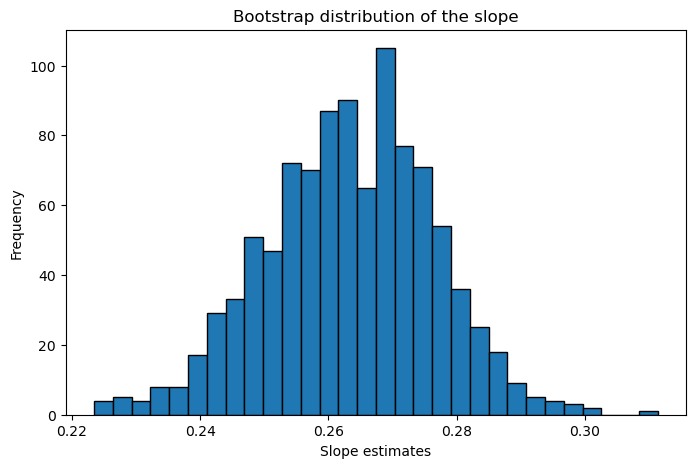

Bootstrap SE(b1): 0.01316
Analytical SE(b1): 0.01291


In [313]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    # Return an array of slope estimates from n_resamples bootstrap replicates.
    rng = np.random.default_rng(seed)

    # TODO 
    # 1. draw an index array of size m with replacement using rng.integers
    # 2. fit the model to the resampled data and store the slope
    # 3. repeat n_resamples times and return the collected slopes
    #1
    m = len(X)
    s = []
    for i in range( n_resamples):
        idx = rng.integers(0,m,size=m)
        #2
        xb = X[idx]
        yb = y[idx]
        temp =  LinearRegression()
        temp.fit(xb,yb)
        s.append(temp.b1)
     #3
    return np.array(s)
    
    raise NotImplementedError("Task A5: complete bootstrap_slope(), then delete this line")


# TODO: plot a histogram of the bootstrap slopes, print their standard deviation,
# and compare it with the analytical SE(b1) obtained above. Comment on the agreement.
s =  bootstrap_slope(X, y)
plt.figure(figsize=(8, 5))
plt.hist(s,bins=30, edgecolor="black")
plt.xlabel("Slope estimates")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of the slope")
plt.show()
bootstrap_se = np.std(s,ddof=1)

print("Bootstrap SE(b1):", round(bootstrap_se, 5))
print("Analytical SE(b1):", round(sb1, 5))

### TASK A6. Written questions 

Answer in the cell below.

1. The fitted slope carries physical units. State them and explain in one sentence what the slope
   means for this dataset.
2. The value of $R^2$ obtained here is well below unity. Give two distinct reasons why a single
   predictor cannot account for all of the variance in the response.
3. Suppose the head size were reported in cubic metres instead of cubic centimetres. State how
   $b_0$, $b_1$, RMSE, and $R^2$ would each change.

## ANSWER A6

### ANSWER 1

The slope has units of **grams per cubic centimetre (g/cm³)** because brain weight is measured in grams and head size is measured in cubic centimetres.

The slope means that **for every increase of 1 cm³ in head size, the predicted brain weight increases by about 0.26 grams**.

### ANSWER 2

The value of **R²** is below 1 because one predictor cannot explain all the changes in brain weight.

1. **Other factors affect brain weight**, such as age, sex, body size, and genetics.

2. **Natural variation and measurement errors** also cause differences in brain weight, even when two people have similar head sizes.

### ANSWER 3

If head size is reported in **cubic metres (m³)** instead of **cubic centimetres (cm³)**:

* **b₀ (intercept):** remains the same.
* **b₁ (slope):** becomes **1,000,000 times larger**.
* **RMSE:** remains the same.
* **R²:** remains the same.

This is because changing the units of head size does not change the quality of the regression fit.


---
# Part B. Logistic regression

## Program 1. Preprocessing and classification on the Titanic dataset with `scikit-learn`

### Aim

To prepare a dataset that contains missing values and categorical columns, and to fit and evaluate
a logistic regression classifier on it.

In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("./datasets/titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### TASK B1. Exploratory visualisation 

The helper below draws a single titled figure. Use it to produce the six plots listed in the
comments.

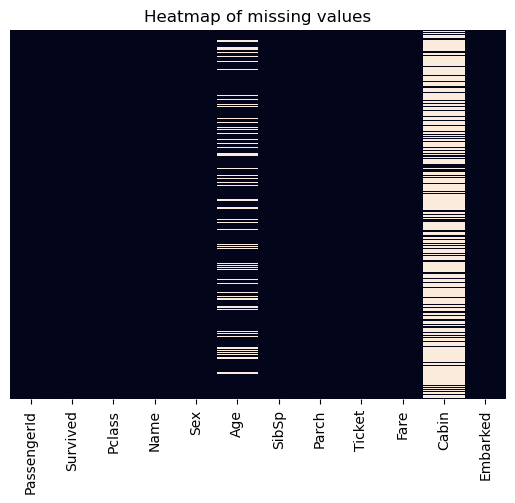

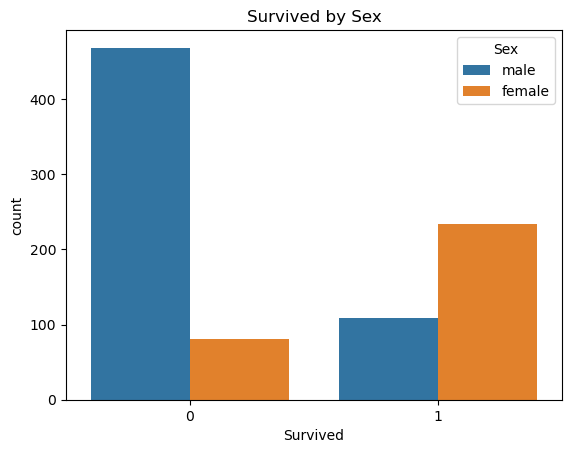

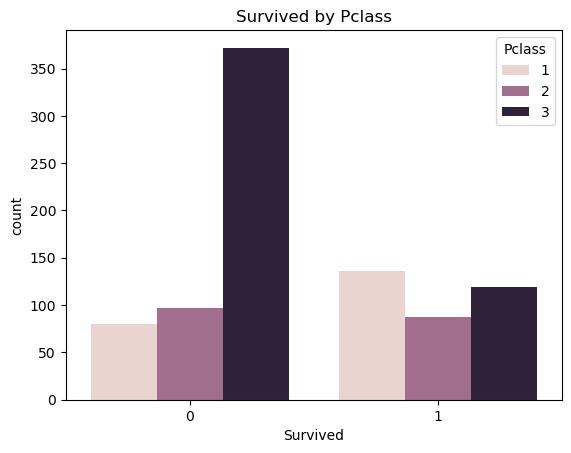

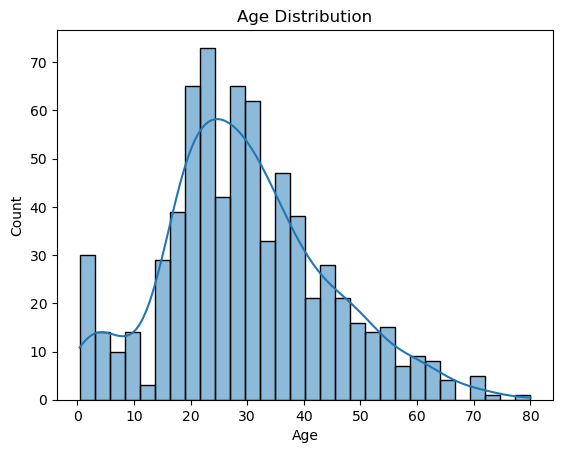

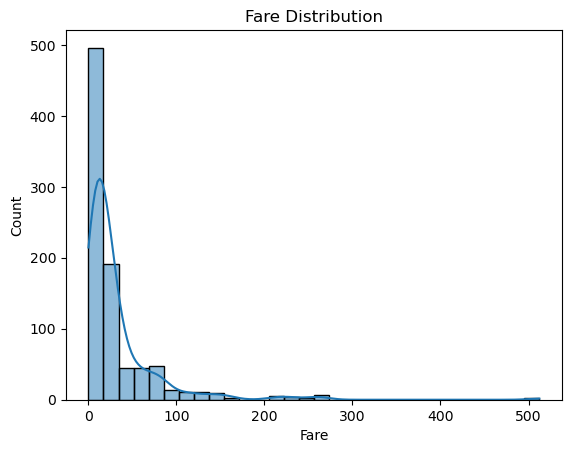

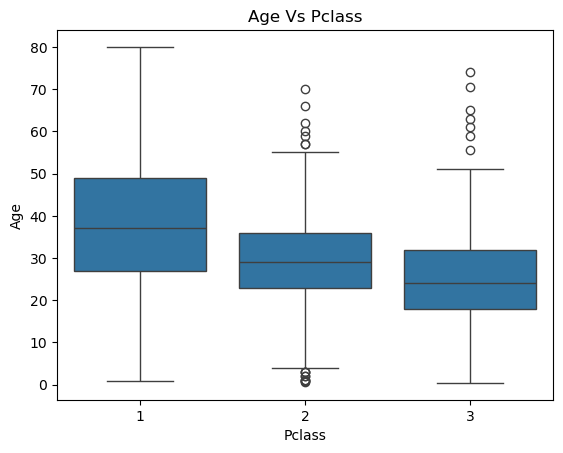

In [321]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()


# TODO : produce the following six figures using the helper above
# 1. a heatmap of titanic_df.isnull() to reveal which columns carry missing values
# 2. a count plot of Survived split by Sex
# 3. a count plot of Survived split by Pclass
# 4. a histogram of Age, with the missing entries dropped
# 5. a histogram of Fare
# 6. a box plot of Age against Pclass

#1
plt.title("Heatmap of missing values")
sns.heatmap(titanic_df.isnull(),cbar = False, yticklabels=False)
plt.show()

#2
plt.title("Survived by Sex")
sns.countplot(data = titanic_df, x ="Survived", hue="Sex")
plt.show()

#3
plt.title("Survived by Pclass")
sns.countplot(data = titanic_df, x ="Survived", hue="Pclass")
plt.show()
#4
plt.title("Age Distribution")
sns.histplot(data = titanic_df["Age"].dropna(), bins = 30,kde = True)
plt.show()
#5
plt.title("Fare Distribution")
sns.histplot(data = titanic_df["Fare"], bins = 30,kde = True)
plt.show()
#6
plt.title("Age Vs Pclass")
sns.boxplot(data = titanic_df, x ="Pclass",y = "Age")
plt.show()



**ANSWER B1.** State which columns carry missing values, and describe in two or three sentences
what the box plot of age against passenger class reveals.

ANSWER : The columns that have missing values are Age, Cabin and Embarked The Cabin column has the missing values while Age has some missing entries and Embarked has only a few.

The box plot of Age versus Passenger Class (Pclass) shows that passengers in class were generally older while passengers in 3rd class were younger. It also shows that the spread of ages is larger in class and that there are some outlies, in each passenger class.

### TASK B2. Missing, categorical, and irrelevant columns 

Missing ages are filled with the mean age of the passenger class rather than with the mean of the
whole column, because age and class are correlated. Complete the imputation, then encode the
categorical columns and remove the columns that carry no predictive value.

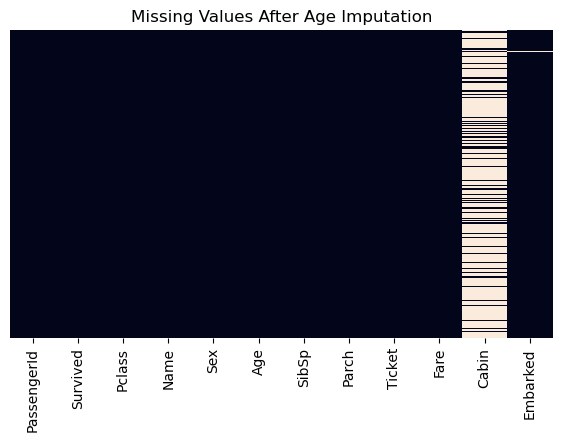

In [325]:
# TODO 
# 1. build a dictionary mean_ages mapping each passenger class to the mean age within that class
# 2. complete impute_missing_age so that a missing age is replaced by the class mean
#    and an age that is already present is returned unchanged
# 3. apply it along axis 1 to the two columns Age and Pclass
# 4. redraw the missing value heatmap to confirm that the Age column is now complete

#1
mean_ages = titanic_df.groupby("Pclass")["Age"].mean().to_dict()

#2
def impute_missing_age(columns):
    age, p_class = columns
    if pd.isnull(age):
        return mean_ages[p_class]
    else:
        return age
    raise NotImplementedError("Task B2: complete impute_missing_age(), then delete this line")

#3
titanic_df["Age"] = titanic_df[["Age","Pclass"]].apply(impute_missing_age,axis=1)

#4
plt.figure(figsize=(7, 4))
plt.title("Missing Values After Age Imputation")
sns.heatmap(titanic_df.isnull(),cbar = False, yticklabels=False)
plt.show()

In [327]:
#TODO 
# 1. drop the Cabin column, which is missing for most passengers, then drop the remaining
#    rows that still contain a missing value
# 2. one-hot encode Sex and Embarked with pd.get_dummies, passing drop_first=True,
#    and concatenate the result to the frame
# 3. drop Name, PassengerId, Ticket, Sex, and Embarked
# 4. display the first five rows of the processed frame
# 1
titanic_df = titanic_df.drop("Cabin",axis = 1)
titanic_df = titanic_df.dropna()
#2
sex = pd.get_dummies(titanic_df["Sex"],drop_first=True)
embarked = pd.get_dummies(titanic_df["Embarked"],drop_first=True) 
titanic_df = pd.concat([titanic_df,sex,embarked],axis = 1)
#3
titanic_df = titanic_df.drop(["Name","PassengerId","Ticket","Sex","Embarked"],axis=1)
4
titanic_df.head()



,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**ANSWER B2.** Explain why `drop_first=True` is used when the categorical columns are encoded,
and what would go wrong if all of the indicator columns were retained.

ANSWER: We use `drop_first=True` to get rid of one column from each group of categories The other columns are enough to show all the categories.

If we keep all the columns we can figure out one column from the other . That causes problems This is called the dummy variable trap multicollineari The dummy variable trap makes the model coefficients hard to understand and not reliable Multicollineari is an issue because it makes the model coefficients unstable
ble

### TASK B3. Fitting and evaluating the classifier 

Scale `Age` and `Fare` to the unit interval before fitting, so that the two columns of large
numerical range do not dominate the optimisation. Fix `random_state` in the split so that your
result is reproducible.

In [331]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

# TODO 
# 1. rescale the Age and Fare columns with minmax_scale
# 2. separate the predictors X from the target y, which is the Survived column
# 3. split into training and test sets with test_size=0.3 and a fixed random_state
# 4. fit a LogisticRegression model and predict on the test set
# 5. print the classification report and the confusion matrix

#1
titanic_df["Age"] = minmax_scale(titanic_df["Age"])
titanic_df["Fare"] =  minmax_scale(titanic_df["Fare"])

#2
X = titanic_df.drop("Survived",axis = 1)
y = titanic_df["Survived"]
#3
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)
#4
model = LogisticRegression()
model.fit(X_train, y_train)
#5
y_pred =model.predict(X_test)
#6
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.83      0.83       167
           1       0.72      0.72      0.72       100

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267

[[139  28]
 [ 28  72]]


### TASK B4. Interpretation 

Answer in the cell below.

1. Write out the confusion matrix you obtained and label the four entries as true positives, false
   positives, true negatives, and false negatives.
2. Define precision and recall in words, and compute both by hand for the survivor class from your
   confusion matrix. Confirm that your values match the classification report.
3. Rerun the split with three different values of `random_state` and record the accuracy each time.
   Comment on the spread and on what it implies about reporting a single accuracy figure.

## ANSWER B4

### 1. Confusion Matrix

The confusion matrix obtained is:

|              | Predicted 0 | Predicted 1 |
| ------------ | ----------- | ----------- |
| **Actual 0** | **139**     | **28**      |
| **Actual 1** | **28**      | **72**      |

The four entries are:

* **True Negatives (TN)** = 139
* **False Positives (FP)** = 28
* **False Negatives (FN)** = 28
* **True Positives (TP)** = 72

### 2. Precision and Recall for the Survivor Class

**Precision** is the proportion of passengers predicted to survive who actually survived.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Substituting the values:

$$
\text{Precision} = \frac{72}{72 + 28}
= \frac{72}{100}
= 0.72
$$

**Recall** is the proportion of passengers who actually survived and were correctly predicted by the model.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Substituting the values:

$$
\text{Recall} = \frac{72}{72 + 28}
= \frac{72}{100}
= 0.72
$$

Therefore, for the survivor class:

* **Precision = 0.72**
* **Recall = 0.72**

These calculated values match the classification report, which also gives **precision = 0.72** and **recall = 0.72** for class **1 (Survived)**.


In [335]:
## ANSWER 3
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

s = [0, 42, 99]
for i in s:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    )

    model = DecisionTreeClassifier(random_state=0)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"random_state = {i}, Accuracy = {accuracy:.3f}")



random_state = 0, Accuracy = 0.730
random_state = 42, Accuracy = 0.770
random_state = 99, Accuracy = 0.708


## Answer 3
The accuracy changes a little for values of random state This shows that how well the model performs depends on the train test split. So showing one accuracy number might not be trustworthy Using splits or cross validation gives a better idea of how the model really works.

---
## Program 2. Logistic regression by gradient descent, compared with `scikit-learn`

### Aim

To implement logistic regression through gradient descent on the log-likelihood, and to compare its
accuracy with the library implementation on the Pima diabetes dataset.

### Theory

$$
\newcommand{\vect}{\mathbf}
\text{Log-likelihood}, \quad LL = \sum_{i=1}^{m} y_i \log(p_i) + (1-y_i)\log(1-p_i)
$$

where

$$
p_i = p(\vect{x}_i, \vect{w}) = \frac{1}{1+e^{-\vect{w}^T\vect{x}_i}}
$$

Here $\vect{w} = (w_0, w_1, \dots, w_n)$ is the weight vector and
$\vect{x}_i = (1, x_{i1}, x_{i2}, \dots, x_{in})$ is the $i$th input vector, the leading unit
entry accounting for the intercept.

The weights are chosen so that

$$
\max_{\vect{w}} LL = \min_{\vect{w}} (-LL)
$$

The gradient of the negative log-likelihood takes the compact form

$$
\frac{d(-LL)}{d\vect{w}} = \sum_{i=1}^{m}(p_i-y_i)\,\vect{x}_i = (\vect{p}-\vect{y})^T X
$$

so that the update step of gradient descent is

$$
\vect{w} := \vect{w} - \alpha\,(\vect{p}-\vect{y})^T X
$$

where $\alpha$ is the learning rate.

### TASK B5. Implementing the classifier 

Complete the class below. No optimisation routine from a library may be used.

In [340]:
import numpy as np
import pandas as pd

In [342]:
class LogitRegression:
    """Binary logistic regression trained by full batch gradient descent."""

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        """Return the predicted probability for a design matrix that already carries
        the leading column of ones."""
        # TODO (1 mark): return the logistic function of X @ self.w
        return 1/(1+np.exp(-X@self.w))
        raise NotImplementedError("Task B5: complete p(), then delete this line")

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)

        # TODO (2 marks): repeat the update step self.iterations times,
        # then return self
        for i in range(self.iterations):
            prob = self.p(X)
            gra = (X.T@(prob - y))/m
            self.w = self.w-self.learning_rate*gra
        return self    
        
        raise NotImplementedError("Task B5: complete fit(), then delete this line")

    def predict(self, X):
        """Return the predicted class label, 0 or 1, for each row of X."""
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])

        # TODO (1 mark): threshold the predicted probability at 0.5
        return (self.p(X) >= 0.5).astype(int)
        raise NotImplementedError("Task B5: complete predict(), then delete this line")

In [344]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("./datasets/diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [346]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100


# TODO: fit both your own LogitRegression, with learning_rate=0.1 and iterations=1000,
# and the library LogisticRegression, then print the test accuracy of each
models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]
for model in models:
    model.fit(X_train,y_train)
    accuracy = compute_accuracy(model, X_test, y_test)
    print(type(model).__name__, "Accuracy:", round(accuracy, 2),"%")


LogitRegression Accuracy: 74.22 %
LogisticRegression Accuracy: 78.91 %


### TASK B6. Effect of the learning rate 

Train your implementation with learning rates of 0.001, 0.01, 0.1, and 1.0, holding the number of
iterations fixed at 1000. Tabulate the test accuracy against the learning rate and comment in two
or three sentences on what you observe at the two extremes.

In [349]:
# TODO : loop over the four learning rates and report the test accuracy of each
lr =  [0.001, 0.01, 0.1, 1.0]
print("Learning Rate                          Test Accuracy")
for l in lr:
    model = LogitRegression(learning_rate=l, iterations=1000)
    model.fit(X_train, y_train)
    accuracy = compute_accuracy(model, X_test, y_test)
    print(lr, "                ", round(accuracy, 2), "%")

Learning Rate                          Test Accuracy
[0.001, 0.01, 0.1, 1.0]                  67.58 %
[0.001, 0.01, 0.1, 1.0]                  67.58 %
[0.001, 0.01, 0.1, 1.0]                  74.22 %
[0.001, 0.01, 0.1, 1.0]                  77.34 %


**ANSWER B6.**

When the learning rate is really small like 0.001 the model learns at a slow pace This means that after 1000 iterations the model may not find the best solution As a result the accuracy of the model can be lower.
On the hand if the learning rate is very large like 1.0 the updates are too big The model learning rate of 1.0 can cause the model to overshoot the optimum which's not good for the accuracy of the model either.
The model learning rate of 0.01 or 0.1 is usually just right The model learning rate like this gives the performance because it is not too slow and not too fast.